In [22]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import glob

In [23]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original:
        with tifffile.TiffFile(compressed_file) as tif_compressed:
            for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                original_image = original_frame.asarray()
                compressed_image = compressed_frame.asarray()
                score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                ssim_scores.append(score)
    return ssim_scores

In [24]:
# Change these paths according to your directory structure
main_folder = '/Users/laurabreimann/Desktop/microtubule_data'
original_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/sequence-MT0.N1.HD-BP-Exp-as-list.tif'

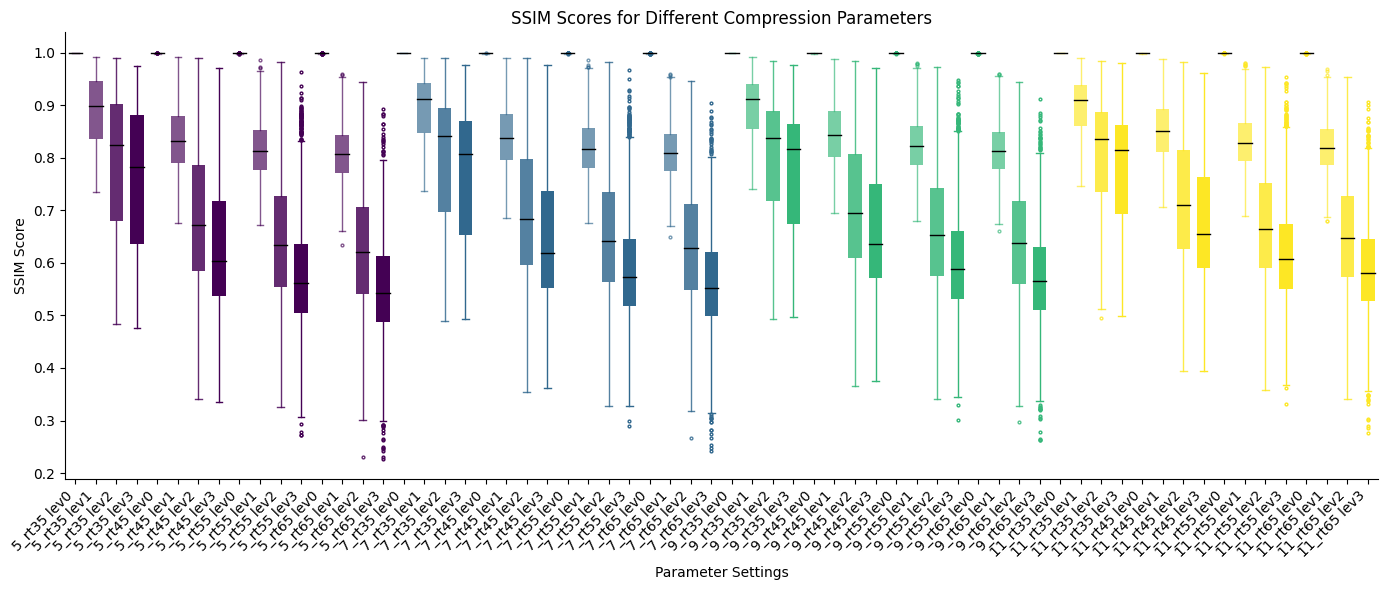

In [26]:
results = {}

# Iterate through each subfolder and calculate SSIM
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        compressed_file = os.path.join(main_folder, folder, 'sequence-MT0.N1.HD-BP.tif')  # Adjust the file name if needed
        scores = calculate_ssim(original_file, compressed_file)
        results[folder] = scores

# Extract 'k' values and levels from folder names for color coding
k_values = set()
levels = set()
for folder in results:
    parts = folder.split('_')
    k_values.add(int(parts[1][1:]))  # Assuming the format is 'k<number>'
    levels.add(int(parts[-1][-1]))  # Assuming the format is 'lev<number>'

k_values = sorted(k_values)
levels = sorted(levels)

# Assign colors based on 'k' values and levels
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
level_shades = np.linspace(0.5, 1, len(levels))

# Create boxplots with colors and remove top and right lines
plt.figure(figsize=(14, 6))
ax = plt.gca()  # Get current axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot each set of SSIM scores with the corresponding color and shade
box_width = 0.65  # You can adjust this value as needed to change the box width
for i, (folder, scores) in enumerate(sorted(results.items(), key=lambda x: natural_sort_key(x[0]))):
    k_value = int(folder.split('_')[1][1:])
    level = int(folder.split('_')[-1][-1])
    color = k_colors[k_values.index(k_value)]
    shade = level_shades[levels.index(level)]
    box = plt.boxplot(scores, positions=[i], widths=box_width, patch_artist=True, 
                      boxprops=dict(facecolor=color, alpha=shade, edgecolor='none'),
                      whiskerprops=dict(color=color, alpha=shade),
                      capprops=dict(color=color, alpha=shade),
                      flierprops=dict(marker='o', color=color, markersize=2, alpha=shade, markeredgecolor=color),
                      medianprops=dict(color='black'))



# Adjust x-axis labels
ax.set_xticklabels([folder.replace('sparz_k', '').replace('_lev', ' lev') for folder in sorted(results.keys(), key=natural_sort_key)], rotation=45, ha='right')
plt.xlabel('Parameter Settings')
plt.ylabel('SSIM Score')
plt.title('SSIM Scores for Different Compression Parameters')
plt.tight_layout()  # Adjust layout to fit everything
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/SSIM_240205.pdf', format='pdf')
plt.show()

In [11]:
# Structure to hold the SSIM scores for each parameter setting
ssim_table = {}

# Iterate through each subfolder and calculate SSIM
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        compressed_file = os.path.join(main_folder, folder, 'sequence-MT0.N1.HD-BP.tiff')  # Adjust the file name if needed
        ssim_table[folder] = calculate_ssim(original_file, compressed_file)

# Print a summary of the SSIM scores for verification
for setting, scores in ssim_table.items():
    print(f"Setting: {setting}, Number of Scores: {len(scores)}, Sample Scores: {scores[:5]}")

Setting: sparz_k5_rt35_lev0, Number of Scores: 2500, Sample Scores: [0.999521315283165, 0.9995718689325503, 0.9988387614109788, 0.9984347597155264, 0.9991691535860696]
Setting: sparz_k5_rt35_lev1, Number of Scores: 2500, Sample Scores: [0.9717243403476589, 0.9409121965574049, 0.851581777942802, 0.7711426489359053, 0.9021149417588668]
Setting: sparz_k5_rt35_lev2, Number of Scores: 2500, Sample Scores: [0.9577030928982967, 0.8990274300386027, 0.6844451236074929, 0.5349689259876665, 0.832857433366662]
Setting: sparz_k5_rt35_lev3, Number of Scores: 2500, Sample Scores: [0.8819301918361894, 0.8868328028784106, 0.6638949264064912, 0.5276691404174038, 0.7839955492888455]
Setting: sparz_k5_rt45_lev0, Number of Scores: 2500, Sample Scores: [0.9987691874512074, 0.998835134756681, 0.9988306405950397, 0.9983651650654995, 0.9984570522968507]
Setting: sparz_k5_rt45_lev1, Number of Scores: 2500, Sample Scores: [0.9261005869584152, 0.8210186581909359, 0.8503736692342194, 0.7594528313456195, 0.80983846

In [2]:
def natural_sort_key(s):
    """
    Extracts the sorting keys from a string.
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split('(\d+)', s)]

def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value



In [10]:

# Path to the single CSV file
csv_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/output/grid-search_metrics.csv'

# Read the CSV file
all_data = pd.read_csv(csv_file)

In [11]:

# Define metrics
metrics = ['Jaccard', 'Wasserstein Average', 'Wasserstein NN distances', 'Histogram', 'Wasserstein X', 'Wasserstein Y', 'Wasserstein Z']
labels = natsorted(all_data['label'].unique(), key=lambda x: [int(t) if t.isdigit() else t.lower() for t in re.split('(\d+)', x)])

print(labels)

['sparz_k5_rt35_lev0', 'sparz_k5_rt35_lev1', 'sparz_k5_rt35_lev2', 'sparz_k5_rt35_lev3', 'sparz_k5_rt45_lev0', 'sparz_k5_rt45_lev1', 'sparz_k5_rt45_lev2', 'sparz_k5_rt45_lev3', 'sparz_k5_rt55_lev0', 'sparz_k5_rt55_lev1', 'sparz_k5_rt55_lev2', 'sparz_k5_rt55_lev3', 'sparz_k5_rt65_lev0', 'sparz_k5_rt65_lev1', 'sparz_k5_rt65_lev2', 'sparz_k5_rt65_lev3', 'sparz_k7_rt35_lev0', 'sparz_k7_rt35_lev1', 'sparz_k7_rt35_lev2', 'sparz_k7_rt35_lev3', 'sparz_k7_rt45_lev0', 'sparz_k7_rt45_lev1', 'sparz_k7_rt45_lev2', 'sparz_k7_rt45_lev3', 'sparz_k7_rt55_lev0', 'sparz_k7_rt55_lev1', 'sparz_k7_rt55_lev2', 'sparz_k7_rt55_lev3', 'sparz_k7_rt65_lev0', 'sparz_k7_rt65_lev1', 'sparz_k7_rt65_lev2', 'sparz_k7_rt65_lev3', 'sparz_k9_rt35_lev0', 'sparz_k9_rt35_lev1', 'sparz_k9_rt35_lev2', 'sparz_k9_rt35_lev3', 'sparz_k9_rt45_lev0', 'sparz_k9_rt45_lev1', 'sparz_k9_rt45_lev2', 'sparz_k9_rt45_lev3', 'sparz_k9_rt55_lev0', 'sparz_k9_rt55_lev1', 'sparz_k9_rt55_lev2', 'sparz_k9_rt55_lev3', 'sparz_k9_rt65_lev0', 'sparz_k9

In [13]:
# Apply the extraction function to all labels
k_values = sorted(set(extract_k_lev(label)[0] for label in labels if extract_k_lev(label)[0] is not None))
lev_values = sorted(set(extract_k_lev(label)[1] for label in labels if extract_k_lev(label)[1] is not None))

# Assign colors based on 'k' values
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
lev_shades = np.linspace(0.5, 1, len(lev_values))

# Plot bar plots
for metric in metrics:
    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ## Filter data for the current metric
    metric_data = all_data[all_data['metric'] == metric]


  # Plot bar for each label
    for i, label in enumerate(labels):
        k_value, lev_value = extract_k_lev(label)
        color = k_colors[k_values.index(k_value)]
        shade = lev_shades[lev_values.index(lev_value)]
        values = metric_data[metric_data['label'] == label]['value']
        values = values.replace([np.inf, -np.inf], np.nan).dropna()  # Remove inf and -inf
        if not values.empty:
            plt.bar(i, values.mean(), color=color, alpha=shade)  # Plot the average value

    # Adjust x-axis labels
    cleaned_labels = [label.replace('sparz_', '') for label in labels]
    plt.xticks(ticks=range(len(cleaned_labels)), labels=cleaned_labels, rotation=45, ha='right')
    plt.xlabel('Label')
    plt.ylabel(f'Average {metric} Value')
    plt.title(f'Average {metric} Values for Different Compression Parameters')



    # Save each plot as a separate PDF
    output_file = f'/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/{metric}_scores.pdf'  # Adjust the path as needed
    plt.tight_layout()
    plt.savefig(output_file, format='pdf')
    plt.close()


In [15]:
# Read the CSV file for number of localizations
loc_csv_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/output/number_of_localizations.csv'
loc_data = pd.read_csv(loc_csv_file)

# Get unique labels and sort them
labels = natsorted(loc_data['label'].unique(), key=lambda x: [int(t) if t.isdigit() else t.lower() for t in re.split('(\d+)', x)])

# Apply the extraction function to all labels
k_values = sorted(set(extract_k_lev(label)[0] for label in labels if extract_k_lev(label)[0] is not None))
lev_values = sorted(set(extract_k_lev(label)[1] for label in labels if extract_k_lev(label)[1] is not None))

# Assign colors based on 'k' values
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
lev_shades = np.linspace(0.5, 1, len(lev_values))

# Plot bar plot for number of localizations
plt.figure(figsize=(14, 6))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot bar for each label
for i, label in enumerate(labels):
    k_value, lev_value = extract_k_lev(label)
    color = k_colors[k_values.index(k_value)]
    shade = lev_shades[lev_values.index(lev_value)]
    values = loc_data[loc_data['label'] == label]['distance']
    if not values.empty:
        plt.bar(i, values.mean(), color=color, alpha=shade)  # Plot the average value

# Add a gray dashed horizontal line at Y = 8000
plt.axhline(y=8000, color='gray', linestyle='--')        

# Adjust x-axis labels
cleaned_labels = [label.replace('sparz_', '') for label in labels]
plt.xticks(ticks=range(len(cleaned_labels)), labels=cleaned_labels, rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Number of Localizations')
plt.title('Number of Localizations for Different Compression Parameters')

# Save the plot as a PDF
output_file = f'/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/number_of_localizations.pdf'  # Adjust the path as needed
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
from natsort import natsorted
import numpy as np
import re

# Function definitions (extract_k_lev, natural_sort_key) go here

# Read the CSV file for NN distances
nn_csv_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/output/grid-search_distances.csv'
nn_data = pd.read_csv(nn_csv_file)

# Get unique labels and sort them
labels = natsorted(nn_data['label'].unique(), key=lambda x: [int(t) if t.isdigit() else t.lower() for t in re.split('(\d+)', x)])

# Apply the extraction function to all labels
k_values = sorted(set(extract_k_lev(label)[0] for label in labels if extract_k_lev(label)[0] is not None))
lev_values = sorted(set(extract_k_lev(label)[1] for label in labels if extract_k_lev(label)[1] is not None))

# Assign colors based on 'k' values
k_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
lev_shades = np.linspace(0.5, 1, len(lev_values))

# Plot box plot for NN distances
plt.figure(figsize=(14, 6))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set y-axis to logarithmic scale and set limits
ax.set_yscale('log')
#ax.set_ylim(bottom=np.nanmin(nn_data['distance'][nn_data['distance'] > 0]))

# Add a red dashed horizontal line at Y = 40
plt.axhline(y=40, color='red', linestyle='--')

# Plot box plot for each label
box_width = 0.65  # You can adjust this value as needed
for i, label in enumerate(labels):
    k_value, lev_value = extract_k_lev(label)
    color = k_colors[k_values.index(k_value)]
    shade = lev_shades[lev_values.index(lev_value)]
    values = nn_data[nn_data['label'] == label]['distance'].tolist()
    if not isinstance(values[0], list):
        values = [values]
    # Draw the boxplot with the correct coloring
    bp = ax.boxplot(values, positions=[i], widths=box_width, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=shade, edgecolor='none'),
                    whiskerprops=dict(color=color, alpha=shade),
                    capprops=dict(color=color, alpha=shade),
                    flierprops=dict(marker='o', color=color, markersize=2, alpha=shade, markeredgecolor='none', markerfacecolor=color),
                    medianprops=dict(color='black'))

# Adjust x-axis labels
cleaned_labels = [label.replace('sparz_k', '') for label in labels]
plt.xticks(ticks=np.arange(1, len(cleaned_labels) + 1), labels=cleaned_labels, rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('NN Distances (log scale)')
plt.title('Nearest Neighbor Distances for Different Compression Parameters')


# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/nn_distances_boxplot_240205.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()
